## 1. Imports

In [1]:
import os
import glob
import copy
import time
import math
import pickle
import warnings
from typing import List, Tuple, Optional
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

try:
    import soundfile as sf
    HAS_SOUNDFILE = True
except ImportError:
    HAS_SOUNDFILE = False
    print("WARNING: soundfile not installed.")

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Device: cpu


## 2. Configuration

In [2]:
from pathlib import Path

# === DATA ===
def is_valid_data_dir(path: Path) -> bool:
    return path.is_dir() and any(path.glob("*/*.csv"))

def find_data_dir(dataset_folder_name: str = "whalesoundsong-main", max_depth: int = 4) -> str:
    candidates = []

    # 1) Optional explicit override (portable across machines)
    env_dir = os.environ.get("WHALE_DATA_DIR")
    if env_dir:
        candidates.append(Path(env_dir).expanduser())

    # 2) Common relative locations from current working directory
    cwd = Path.cwd()
    candidates.extend([
        cwd / dataset_folder_name,
        cwd.parent / dataset_folder_name,
        cwd / "data" / dataset_folder_name,
        cwd.parent / "data" / dataset_folder_name,
    ])

    # 3) Search nearby folders up to max_depth
    search_roots = [cwd, cwd.parent]
    for root in search_roots:
        if not root.exists():
            continue
        try:
            for path in root.rglob(dataset_folder_name):
                try:
                    depth = len(path.relative_to(root).parts)
                except ValueError:
                    continue
                if depth <= max_depth:
                    candidates.append(path)
        except PermissionError:
            continue

    seen = set()
    checked = []
    for c in candidates:
        c = c.resolve()
        if c in seen:
            continue
        seen.add(c)
        checked.append(str(c))
        if is_valid_data_dir(c):
            return str(c)

    raise FileNotFoundError(
        "Could not find dataset folder 'whalesoundsong-main'. "
        "Set WHALE_DATA_DIR or place the folder near this notebook. Checked: "
        + ", ".join(checked[:20])
    )

DATA_DIR = find_data_dir()
print(f"Using DATA_DIR: {DATA_DIR}")

# === SPECTROGRAM ===
SAMPLE_RATE = 22050
DURATION = None            # None = use full clip length
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
TARGET_WIDTH = 256

# === BACKGROUND CLASS ===
INCLUDE_BACKGROUND = False
MAX_BG_PER_SPECIES = 5

# === DIFFUSION ===
DIFFUSION_EPOCHS = 200       # Epochs to train the diffusion model
DIFFUSION_LR = 1e-3
DIFFUSION_BATCH_SIZE = 16
TIMESTEPS = 500              # Number of diffusion steps (fewer = faster, less quality)
SYNTH_PER_CLASS = 50         # How many synthetic samples to generate per class
IMG_SIZE = 64                # Downsample spectrograms for diffusion (faster training)
                             # The CNN still gets 128x256 - synthetics are upscaled

# === CNN TRAINING ===
BATCH_SIZE = 32
EPOCHS = 75
LEARNING_RATE = 0.0005
EARLY_STOP_PATIENCE = 10
TEST_SIZE = 0.20
VAL_SIZE = 0.15

print(f"Diffusion: {TIMESTEPS} steps, {DIFFUSION_EPOCHS} epochs, {SYNTH_PER_CLASS} synthetic/class")
print(f"CNN: {EPOCHS} epochs, batch={BATCH_SIZE}")

Using DATA_DIR: C:\Users\faele\Downloads\Whale_final\whalesoundsong-main
Diffusion: 500 steps, 200 epochs, 50 synthetic/class
CNN: 75 epochs, batch=32


## 3. Audio Processing

In [3]:
def load_audio(audio_path: str, target_sr: int = SAMPLE_RATE,
               duration: Optional[float] = DURATION):
    audio_path = str(audio_path)

    if HAS_SOUNDFILE:
        try:
            audio, sr = sf.read(audio_path)
            if len(audio.shape) > 1:
                audio = np.mean(audio, axis=1)
            audio = audio.astype(np.float32)
        except Exception:
            audio, sr = None, None
    else:
        audio, sr = None, None

    if audio is None:
        try:
            import subprocess
            cmd = ['ffmpeg', '-y', '-i', audio_path, '-f', 's16le',
                   '-acodec', 'pcm_s16le', '-ac', '1', '-ar', str(target_sr), 'pipe:1']
            result = subprocess.run(cmd, capture_output=True, timeout=120)
            if result.returncode != 0:
                return None, None
            audio = np.frombuffer(result.stdout, dtype=np.int16).astype(np.float32) / 32768.0
            sr = target_sr
        except Exception:
            return None, None

    if sr != target_sr:
        audio = signal.resample_poly(audio, target_sr, sr)
        sr = target_sr

    if duration is not None:
        target_length = int(target_sr * duration)
        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)), mode='constant')
        else:
            audio = audio[:target_length]

    max_val = np.max(np.abs(audio))
    if max_val > 0:
        audio = audio / max_val

    return audio.astype(np.float32), sr

## 4. Mel Spectrogram

In [4]:
def compute_mel_spectrogram(audio, sr, n_fft=N_FFT, hop_length=HOP_LENGTH,
                            n_mels=N_MELS, fmin=20, fmax=8000, target_width=TARGET_WIDTH):
    try:
        if fmax is None:
            fmax = sr / 2.0

        noverlap = n_fft - hop_length

        _, _, Sxx = signal.spectrogram(
            audio,
            fs=sr,
            window='hann',
            nperseg=n_fft,
            noverlap=noverlap,
            nfft=n_fft,
            scaling='density',
            mode='magnitude'
        )

        mel_fb = create_mel_filterbank(sr, n_fft, n_mels, fmin, fmax)
        mel_spec = mel_fb @ (Sxx ** 2)

        mel_db = 10.0 * np.log10(np.maximum(mel_spec, 1e-10))

        floor = mel_db.max() - 80.0
        mel_db = np.maximum(mel_db, floor)
        mel_norm = (mel_db - floor) / 80.0
        mel_norm = mel_norm.astype(np.float32)

        if mel_norm.shape[1] != target_width:
            img = Image.fromarray((mel_norm * 255).astype(np.uint8))
            img = img.resize((target_width, n_mels), Image.BILINEAR)
            mel_norm = np.array(img).astype(np.float32) / 255.0

        return mel_norm

    except Exception as e:
        print(f"Spectrogram error: {e}")
        return None

In [5]:
def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mel):
    return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)

def create_mel_filterbank(sr, n_fft, n_mels=128, fmin=0, fmax=None):
    if fmax is None:
        fmax = sr / 2.0
    n_freqs = n_fft // 2 + 1
    mel_min, mel_max = hz_to_mel(fmin), hz_to_mel(fmax)
    mel_points = np.linspace(mel_min, mel_max, n_mels + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((n_fft + 1) * hz_points / sr).astype(int)

    fb = np.zeros((n_mels, n_freqs))
    for i in range(n_mels):
        l, c, r = bins[i], bins[i+1], bins[i+2]
        for j in range(l, c):
            if j < n_freqs:
                fb[i, j] = (j - l) / max(c - l, 1)
        for j in range(c, r):
            if j < n_freqs:
                fb[i, j] = (r - j) / max(r - c, 1)
    return fb

## 5. Load Dataset

In [6]:
def load_sorted_dataset(data_dir=DATA_DIR, include_background=True, max_bg_per_species=5):
    all_specs, all_labels = [], []
    stats = {}
    species_dirs = sorted([d for d in os.listdir(data_dir)
                           if os.path.isdir(os.path.join(data_dir, d))
                           and not d.startswith('.') and not d.startswith('__')])
    print(f"Found {len(species_dirs)} species folders\n")

    for folder_name in species_dirs:
        folder_path = os.path.join(data_dir, folder_name)
        csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
        if not csv_files:
            continue

        df = pd.read_csv(csv_files[0])

        # Detect filename column
        file_col = None
        for c in ['file', 'filename', 'File']:
            if c in df.columns: file_col = c; break
        if file_col is None:
            for col in df.columns:
                if df[col].dtype == object and df[col].str.contains('.wav', case=False, na=False).any():
                    file_col = col; break
        if file_col is None:
            continue

        # Detect labels
        if 'has_sound' in df.columns:
            df['has_sound'] = pd.to_numeric(df['has_sound'].astype(str).str.strip(), errors='coerce').fillna(-1).astype(int)
            positives = df[df['has_sound'] == 1]
            negatives = df[df['has_sound'] == 0]
        else:
            positives = df
            negatives = pd.DataFrame()

        def _load_clip(row):
            fn = row[file_col]
            path = os.path.join(folder_path, fn)
            if not os.path.exists(path):
                path = os.path.join(folder_path, f"{folder_name}_{fn}")
            if not os.path.exists(path):
                return None
            audio, sr = load_audio(path)
            if audio is None: return None
            return compute_mel_spectrogram(audio, sr)

        pos_loaded = 0
        for _, row in positives.iterrows():
            spec = _load_clip(row)
            if spec is not None:
                all_specs.append(spec)
                all_labels.append(folder_name)
                pos_loaded += 1

        bg_loaded = 0
        if include_background and len(negatives) > 0:
            for _, row in negatives.sample(n=min(max_bg_per_species, len(negatives)), random_state=42).iterrows():
                spec = _load_clip(row)
                if spec is not None:
                    all_specs.append(spec)
                    all_labels.append("Background")
                    bg_loaded += 1

        bg_info = f" + {bg_loaded} bg" if bg_loaded > 0 else ""
        print(f"  [{folder_name}] {pos_loaded} positive{bg_info}")

    X = np.array(all_specs, dtype=np.float32)[:, np.newaxis, :, :]
    le = LabelEncoder()
    y = le.fit_transform(all_labels)

    counts = Counter(all_labels)
    print(f"\n{'='*60}")
    print(f"Total: {len(X)} samples, {len(le.classes_)} classes")
    for cls in sorted(counts): print(f"  {cls:40s} {counts[cls]:>4d}")
    return X, y, le, counts

## 6. Load Data

In [7]:
X, y, label_encoder, class_counts = load_sorted_dataset(DATA_DIR, INCLUDE_BACKGROUND, MAX_BG_PER_SPECIES)
num_classes = len(label_encoder.classes_)
print(f"\nReady: {len(X)} samples, {num_classes} classes")

Found 22 species folders

  [Atlantic_Spotted_Dolphin] 41 positive
  [Beluga_White_Whale] 34 positive
  [Bottlenose_Dolphin] 18 positive
  [Bowhead_Whale] 35 positive
  [Clymene_Dolphin] 34 positive
  [Common_Dolphin] 34 positive
  [False_Killer_Whale] 42 positive
  [Finback_Whale] 36 positive
  [Humpback_Whale] 39 positive
  [Killer_Whale] 23 positive
  [Long-Finned_Pilot_Whale] 48 positive
  [Narwhal] 29 positive
  [Northern_Right_Whale] 100 positive
  [Pantropical_Spotted_Dolphin] 33 positive
  [Rough-Toothed_Dolphin] 32 positive
  [Short-Finned_Pacific_Pilot_Whale] 48 positive
  [Southern_Right_Whale] 13 positive
  [Sperm_Whale] 38 positive
  [Spinner_Dolphin] 40 positive
  [Striped_Dolphin] 25 positive
  [White-beaked_Dolphin] 33 positive
  [White-sided_Dolphin] 31 positive

Total: 806 samples, 22 classes
  Atlantic_Spotted_Dolphin                   41
  Beluga_White_Whale                         34
  Bottlenose_Dolphin                         18
  Bowhead_Whale                   

## 7. Split Data (hold out test set BEFORE augmentation)

In [8]:
# CRITICAL: Split BEFORE diffusion augmentation so test set is 100% real data
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y)

print(f"Train+Val (for diffusion + CNN): {len(X_trainval)}")
print(f"Test (real data only):           {len(X_test)}")

Train+Val (for diffusion + CNN): 644
Test (real data only):           162


---
# Diffusion Model

A lightweight class-conditional DDPM that learns to generate mel spectrograms
at a reduced resolution (64×64) for speed. Generated images are upscaled
to 128×256 before being fed to the CNN.

## 8. Diffusion Noise Schedule

In [9]:
def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    """Linear variance schedule from DDPM paper."""
    return torch.linspace(beta_start, beta_end, timesteps)

def get_diffusion_params(timesteps):
    """Precompute all diffusion parameters."""
    betas = linear_beta_schedule(timesteps)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

    return {
        'betas': betas,
        'alphas': alphas,
        'alphas_cumprod': alphas_cumprod,
        'alphas_cumprod_prev': alphas_cumprod_prev,
        'sqrt_alphas_cumprod': torch.sqrt(alphas_cumprod),
        'sqrt_one_minus_alphas_cumprod': torch.sqrt(1.0 - alphas_cumprod),
        'sqrt_recip_alphas': torch.sqrt(1.0 / alphas),
        'posterior_variance': betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod),
    }

diffusion_params = get_diffusion_params(TIMESTEPS)
# Move all to device
for k in diffusion_params:
    diffusion_params[k] = diffusion_params[k].to(device)

print(f"Diffusion schedule: {TIMESTEPS} steps, beta [{diffusion_params['betas'][0]:.4f}, {diffusion_params['betas'][-1]:.4f}]")

Diffusion schedule: 500 steps, beta [0.0001, 0.0200]


## 9. U-Net Denoiser (Conditional)

In [10]:
class SinusoidalPosEmb(nn.Module):
    """Timestep embedding using sinusoidal encoding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, num_classes=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn1 = nn.GroupNorm(8, out_ch)
        self.bn2 = nn.GroupNorm(8, out_ch)
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.class_emb = nn.Embedding(num_classes, out_ch) if num_classes else None

    def forward(self, x, t_emb, c=None):
        h = F.gelu(self.bn1(self.conv1(x)))
        # Add time embedding
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        # Add class embedding
        if self.class_emb is not None and c is not None:
            h = h + self.class_emb(c)[:, :, None, None]
        h = F.gelu(self.bn2(self.conv2(h)))
        return h


class SimpleUNet(nn.Module):
    """
    Lightweight conditional U-Net for spectrogram diffusion.
    Input: (batch, 1, IMG_SIZE, IMG_SIZE)
    Condition: class label (integer)
    Output: predicted noise, same shape as input
    """
    def __init__(self, img_size=64, num_classes=10, time_dim=128, base_ch=64):
        super().__init__()
        self.time_dim = time_dim
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.GELU(),
        )

        # Encoder (downsampling)
        self.enc1 = ConvBlock(1, base_ch, time_dim, num_classes)
        self.enc2 = ConvBlock(base_ch, base_ch*2, time_dim, num_classes)
        self.enc3 = ConvBlock(base_ch*2, base_ch*4, time_dim, num_classes)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bot = ConvBlock(base_ch*4, base_ch*4, time_dim, num_classes)

        # Decoder (upsampling)
        self.up3 = nn.ConvTranspose2d(base_ch*4, base_ch*4, 2, stride=2)
        self.dec3 = ConvBlock(base_ch*8, base_ch*2, time_dim, num_classes)
        self.up2 = nn.ConvTranspose2d(base_ch*2, base_ch*2, 2, stride=2)
        self.dec2 = ConvBlock(base_ch*4, base_ch, time_dim, num_classes)
        self.up1 = nn.ConvTranspose2d(base_ch, base_ch, 2, stride=2)
        self.dec1 = ConvBlock(base_ch*2, base_ch, time_dim, num_classes)

        self.out_conv = nn.Conv2d(base_ch, 1, 1)

    def forward(self, x, t, c):
        t_emb = self.time_mlp(t)

        # Encoder
        e1 = self.enc1(x, t_emb, c)
        e2 = self.enc2(self.pool(e1), t_emb, c)
        e3 = self.enc3(self.pool(e2), t_emb, c)

        # Bottleneck
        b = self.bot(self.pool(e3), t_emb, c)

        # Decoder with skip connections
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1), t_emb, c)
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1), t_emb, c)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1), t_emb, c)

        return self.out_conv(d1)


print(f"U-Net defined: {IMG_SIZE}×{IMG_SIZE} input, {num_classes} classes")

U-Net defined: 64×64 input, 22 classes


## 10. Diffusion Training

In [11]:
def q_sample(x_0, t, noise, params):
    """Forward diffusion: add noise to x_0 at timestep t."""
    sqrt_ac = params['sqrt_alphas_cumprod'][t][:, None, None, None]
    sqrt_omac = params['sqrt_one_minus_alphas_cumprod'][t][:, None, None, None]
    return sqrt_ac * x_0 + sqrt_omac * noise


def train_diffusion(model, X_train, y_train, params, epochs=DIFFUSION_EPOCHS,
                    lr=DIFFUSION_LR, batch_size=DIFFUSION_BATCH_SIZE):
    """Train the conditional diffusion model."""
    # Resize spectrograms to IMG_SIZE × IMG_SIZE for diffusion
    X_small = []
    for i in range(len(X_train)):
        img = Image.fromarray((X_train[i, 0] * 255).astype(np.uint8))
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        X_small.append(np.array(img).astype(np.float32) / 255.0)
    X_small = np.array(X_small)[:, np.newaxis, :, :]

    # Scale to [-1, 1] for diffusion
    X_tensor = torch.FloatTensor(X_small * 2.0 - 1.0).to(device)
    y_tensor = torch.LongTensor(y_train).to(device)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.train()
    losses = []

    print(f"Training diffusion model on {len(X_tensor)} samples ({IMG_SIZE}×{IMG_SIZE})...")
    t0 = time.time()

    for epoch in range(epochs):
        epoch_loss = 0.0
        n_batches = 0

        for x_batch, y_batch in loader:
            noise = torch.randn_like(x_batch)
            t = torch.randint(0, TIMESTEPS, (x_batch.size(0),), device=device)

            x_noisy = q_sample(x_batch, t, noise, params)
            noise_pred = model(x_noisy, t, y_batch)
            loss = F.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        scheduler.step()
        avg_loss = epoch_loss / max(n_batches, 1)
        losses.append(avg_loss)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:>3d}/{epochs} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.1e}")

    elapsed = time.time() - t0
    print(f"Diffusion training done in {elapsed/60:.1f} min")
    return losses

## 11. Sample Generation

In [12]:
@torch.no_grad()
def generate_samples(model, params, class_label, n_samples, img_size=IMG_SIZE):
    """Generate spectrograms via reverse diffusion (DDPM sampling)."""
    model.eval()

    c = torch.full((n_samples,), class_label, dtype=torch.long, device=device)
    x = torch.randn(n_samples, 1, img_size, img_size, device=device)

    for t_idx in reversed(range(TIMESTEPS)):
        t = torch.full((n_samples,), t_idx, dtype=torch.long, device=device)

        # Predict noise
        noise_pred = model(x, t, c)

        # DDPM reverse step
        alpha = params['alphas'][t_idx]
        alpha_bar = params['alphas_cumprod'][t_idx]
        beta = params['betas'][t_idx]

        # Mean
        x = (1.0 / torch.sqrt(alpha)) * (
            x - (beta / torch.sqrt(1.0 - alpha_bar)) * noise_pred
        )

        # Add noise (except at t=0)
        if t_idx > 0:
            noise = torch.randn_like(x)
            x = x + torch.sqrt(params['posterior_variance'][t_idx]) * noise

    # Scale back to [0, 1]
    x = (x.clamp(-1, 1) + 1) / 2.0
    return x.cpu().numpy()


def upscale_to_full(samples_small, target_h=N_MELS, target_w=TARGET_WIDTH):
    """Upscale generated IMG_SIZE×IMG_SIZE samples to N_MELS×TARGET_WIDTH."""
    results = []
    for i in range(len(samples_small)):
        img = Image.fromarray((samples_small[i, 0] * 255).astype(np.uint8))
        img = img.resize((target_w, target_h), Image.BILINEAR)
        results.append(np.array(img).astype(np.float32) / 255.0)
    return np.array(results)[:, np.newaxis, :, :]


print("Generation functions defined.")

Generation functions defined.


## 12. Train Diffusion Model

U-Net parameters: 3,867,009
Training diffusion model on 644 samples (64×64)...
  Epoch   1/200 | Loss: 0.1842 | LR: 1.0e-03
  Epoch  20/200 | Loss: 0.0326 | LR: 9.8e-04
  Epoch  40/200 | Loss: 0.0285 | LR: 9.0e-04
  Epoch  60/200 | Loss: 0.0248 | LR: 7.9e-04
  Epoch  80/200 | Loss: 0.0233 | LR: 6.5e-04
  Epoch 100/200 | Loss: 0.0272 | LR: 5.0e-04
  Epoch 120/200 | Loss: 0.0216 | LR: 3.5e-04
  Epoch 140/200 | Loss: 0.0261 | LR: 2.1e-04
  Epoch 160/200 | Loss: 0.0249 | LR: 9.5e-05
  Epoch 180/200 | Loss: 0.0225 | LR: 2.4e-05
  Epoch 200/200 | Loss: 0.0222 | LR: 0.0e+00
Diffusion training done in 78.7 min


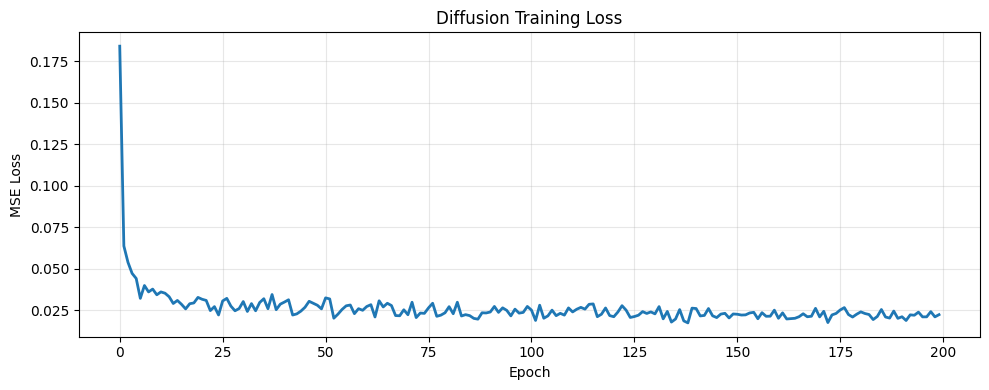

In [13]:
unet = SimpleUNet(img_size=IMG_SIZE, num_classes=num_classes, time_dim=128, base_ch=64).to(device)

total_params = sum(p.numel() for p in unet.parameters())
print(f"U-Net parameters: {total_params:,}")

diffusion_losses = train_diffusion(unet, X_trainval, y_trainval, diffusion_params)

# Plot loss
plt.figure(figsize=(10, 4))
plt.plot(diffusion_losses, linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Diffusion Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Generate Synthetic Data

In [14]:
print(f"Generating {SYNTH_PER_CLASS} synthetic samples per class ({num_classes} classes)...\n")

X_synthetic = []
y_synthetic = []

for cls_idx in range(num_classes):
    cls_name = label_encoder.inverse_transform([cls_idx])[0]
    real_count = (y_trainval == cls_idx).sum()

    # Generate samples
    samples_small = generate_samples(unet, diffusion_params, cls_idx, SYNTH_PER_CLASS)
    samples_full = upscale_to_full(samples_small)

    X_synthetic.append(samples_full)
    y_synthetic.extend([cls_idx] * SYNTH_PER_CLASS)

    print(f"  {cls_name:40s} real={real_count:>3d}  +{SYNTH_PER_CLASS} synthetic")

X_synthetic = np.concatenate(X_synthetic, axis=0)
y_synthetic = np.array(y_synthetic)

print(f"\nSynthetic dataset: {X_synthetic.shape}")
print(f"Total augmented: {len(X_trainval)} real + {len(X_synthetic)} synthetic = {len(X_trainval) + len(X_synthetic)}")

Generating 50 synthetic samples per class (22 classes)...

  Atlantic_Spotted_Dolphin                 real= 33  +50 synthetic
  Beluga_White_Whale                       real= 27  +50 synthetic
  Bottlenose_Dolphin                       real= 15  +50 synthetic
  Bowhead_Whale                            real= 28  +50 synthetic
  Clymene_Dolphin                          real= 27  +50 synthetic
  Common_Dolphin                           real= 27  +50 synthetic
  False_Killer_Whale                       real= 34  +50 synthetic
  Finback_Whale                            real= 29  +50 synthetic
  Humpback_Whale                           real= 31  +50 synthetic
  Killer_Whale                             real= 18  +50 synthetic
  Long-Finned_Pilot_Whale                  real= 38  +50 synthetic
  Narwhal                                  real= 23  +50 synthetic
  Northern_Right_Whale                     real= 80  +50 synthetic
  Pantropical_Spotted_Dolphin              real= 26  +50 synthetic
  R

## 14. Visualize: Real vs Synthetic

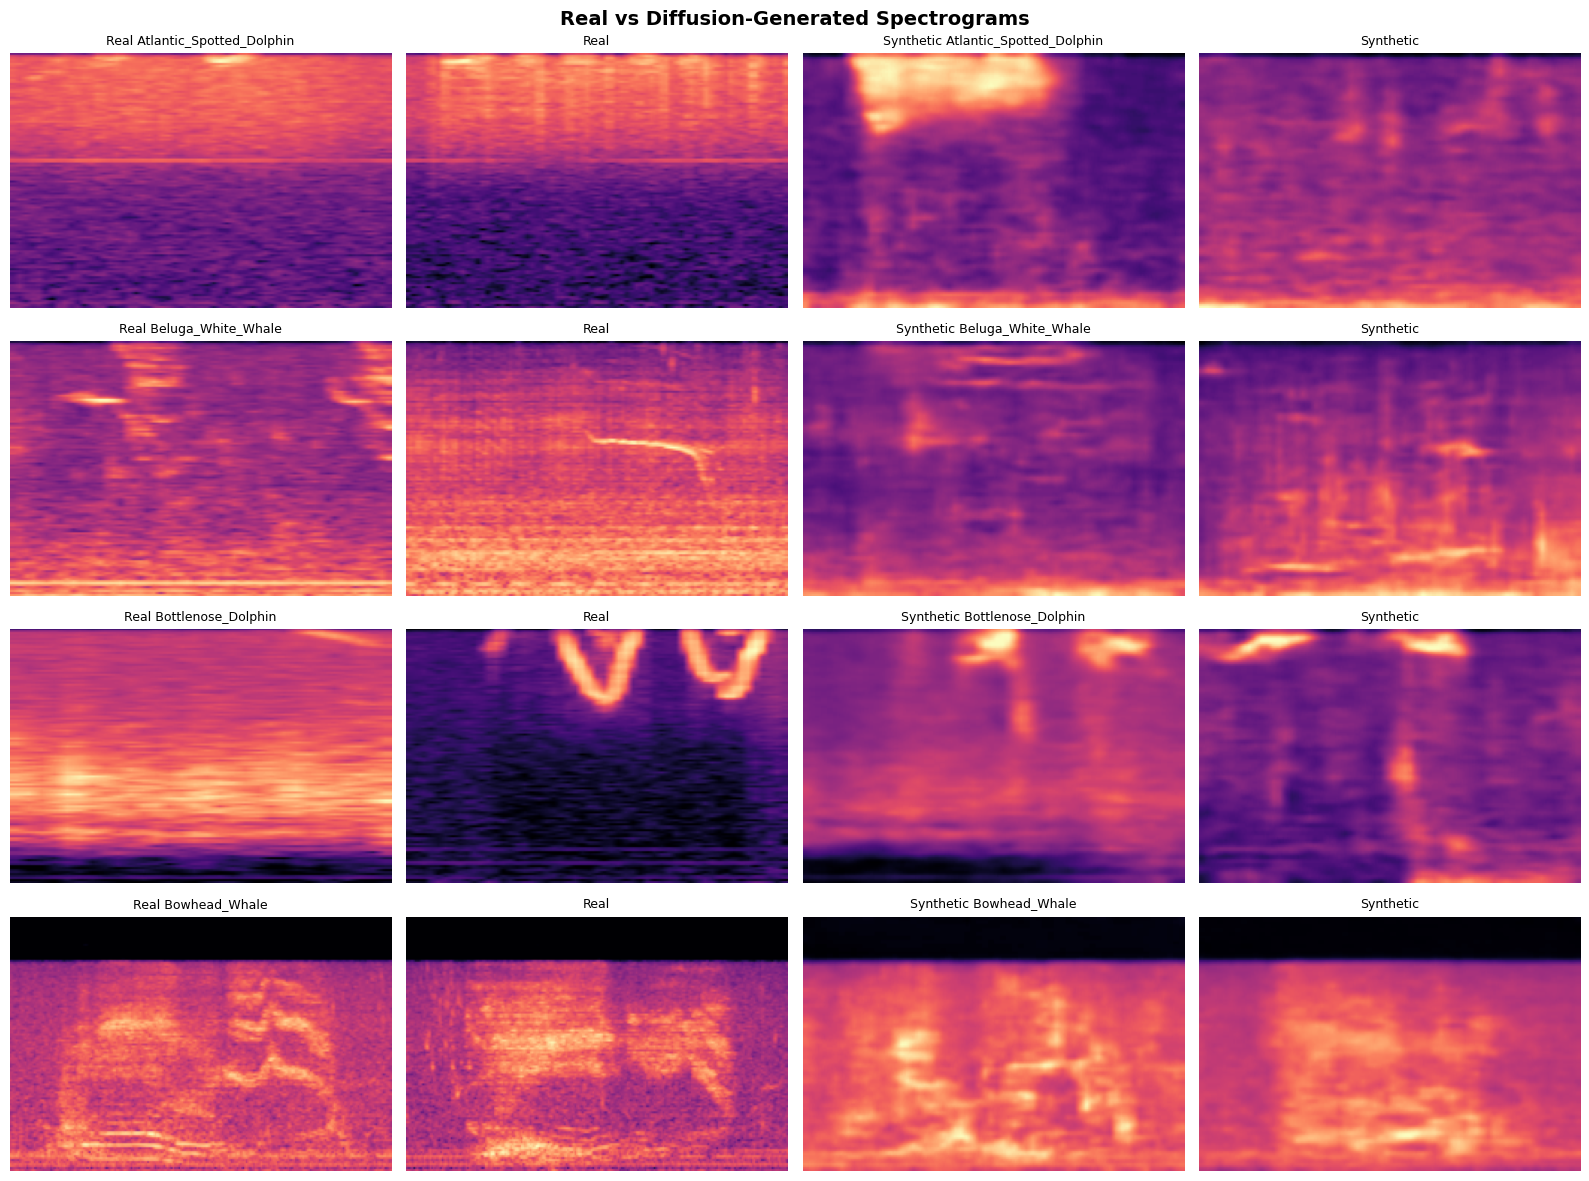

In [15]:
# Show side-by-side comparisons for a few classes
n_show = min(4, num_classes)
fig, axes = plt.subplots(n_show, 4, figsize=(16, 3 * n_show))
if n_show == 1: axes = axes[np.newaxis, :]

for i in range(n_show):
    cls_idx = i
    cls_name = label_encoder.inverse_transform([cls_idx])[0]

    # Real samples
    real_mask = y_trainval == cls_idx
    real_samples = X_trainval[real_mask]

    # Synthetic samples
    synth_mask = y_synthetic == cls_idx
    synth_samples = X_synthetic[synth_mask]

    for j in range(2):
        if j < len(real_samples):
            axes[i, j].imshow(real_samples[j, 0], aspect='auto', origin='lower', cmap='magma')
        axes[i, j].set_title(f'Real {cls_name}' if j == 0 else 'Real', fontsize=9)
        axes[i, j].axis('off')

    for j in range(2):
        if j < len(synth_samples):
            axes[i, j+2].imshow(synth_samples[j, 0], aspect='auto', origin='lower', cmap='magma')
        axes[i, j+2].set_title(f'Synthetic {cls_name}' if j == 0 else 'Synthetic', fontsize=9)
        axes[i, j+2].axis('off')

plt.suptitle('Real vs Diffusion-Generated Spectrograms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Combine Real + Synthetic Data

In [16]:
# ------------------------------------------------------------
# Split REAL trainval data first
# ------------------------------------------------------------
rel_val = VAL_SIZE / (1 - TEST_SIZE)

X_train_real, X_val, y_train_real, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=rel_val,
    random_state=42,
    stratify=y_trainval
)

print(f"Real train: {len(X_train_real)}")
print(f"Real val:   {len(X_val)}")
print(f"Real test:  {len(X_test)}")

# ------------------------------------------------------------
# Optional: cap synthetic data so it does not dominate training
# ------------------------------------------------------------
max_synth = len(X_train_real)

if len(X_synthetic) > max_synth:
    synth_perm = np.random.permutation(len(X_synthetic))[:max_synth]
    X_synth_used = X_synthetic[synth_perm]
    y_synth_used = y_synthetic[synth_perm]
else:
    X_synth_used = X_synthetic
    y_synth_used = y_synthetic

print(f"Synthetic used: {len(X_synth_used)}")

# ------------------------------------------------------------
# Add synthetic ONLY to training set
# ------------------------------------------------------------
X_train = np.concatenate([X_train_real, X_synth_used], axis=0)
y_train = np.concatenate([y_train_real, y_synth_used], axis=0)

# Shuffle combined training set
perm = np.random.permutation(len(X_train))
X_train = X_train[perm]
y_train = y_train[perm]

print(f"\nFinal training set: {len(X_train)} (real + synthetic)")
print(f"Validation set:     {len(X_val)} (real only)")
print(f"Test set:           {len(X_test)} (real only)")

Real train: 523
Real val:   121
Real test:  162
Synthetic used: 523

Final training set: 1046 (real + synthetic)
Validation set:     121 (real only)
Test set:           162 (real only)


## 16. PyTorch DataLoaders

In [17]:
class WhaleSpectrogramDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        spec = self.X[idx].clone()

        if self.augment:
            _, h, w = spec.shape

            # Frequency masking
            f = torch.randint(0, min(15, h), (1,)).item()
            if f > 0:
                f0 = torch.randint(0, max(1, h - f + 1), (1,)).item()
                spec[:, f0:f0 + f, :] = 0

            # Time masking
            t = torch.randint(0, min(25, w), (1,)).item()
            if t > 0:
                t0 = torch.randint(0, max(1, w - t + 1), (1,)).item()
                spec[:, :, t0:t0 + t] = 0

        return spec, self.y[idx]


train_dataset = WhaleSpectrogramDataset(X_train, y_train, augment=True)
val_dataset = WhaleSpectrogramDataset(X_val, y_val, augment=False)
test_dataset = WhaleSpectrogramDataset(X_test, y_test, augment=False)

# Weighted sampling for class imbalance
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
sample_weights = class_weights[y_train]
sample_weights = torch.DoubleTensor(sample_weights)

train_sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Loaders ready: {len(train_loader)} train batches, {len(val_loader)} val, {len(test_loader)} test")

Loaders ready: 32 train batches, 4 val, 6 test


## 17. CNN Model

In [18]:
class WhaleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1a = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1a = nn.BatchNorm2d(32)
        self.conv1b = nn.Conv2d(32, 32, 3, padding=1)
        self.bn1b = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)
        self.drop1 = nn.Dropout(0.20)

        self.conv2a = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2a = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, 3, padding=1)
        self.bn2b = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)
        self.drop2 = nn.Dropout(0.20)

        self.conv3a = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3a = nn.BatchNorm2d(128)
        self.conv3b = nn.Conv2d(128, 128, 3, padding=1)
        self.bn3b = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)
        self.drop3 = nn.Dropout(0.25)

        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2)
        self.drop4 = nn.Dropout(0.25)

        self.adaptive = nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = nn.Linear(256, 128)
        self.bnf1 = nn.BatchNorm1d(128)
        self.df1 = nn.Dropout(0.35)

        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1a(self.conv1a(x)))
        x = F.relu(self.bn1b(self.conv1b(x)))
        x = self.drop1(self.pool1(x))

        x = F.relu(self.bn2a(self.conv2a(x)))
        x = F.relu(self.bn2b(self.conv2b(x)))
        x = self.drop2(self.pool2(x))

        x = F.relu(self.bn3a(self.conv3a(x)))
        x = F.relu(self.bn3b(self.conv3b(x)))
        x = self.drop3(self.pool3(x))

        x = F.relu(self.bn4(self.conv4(x)))
        x = self.drop4(self.pool4(x))

        x = self.adaptive(x)
        x = x.view(x.size(0), -1)

        x = self.df1(F.relu(self.bnf1(self.fc1(x))))
        x = self.fc2(x)
        return x


model = WhaleCNN(num_classes).to(device)
print(f"CNN: {sum(p.numel() for p in model.parameters()):,} parameters")

CNN: 618,998 parameters


## 18. Train CNN

In [19]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        loss_sum += loss.item() * x.size(0)
        _, pred = torch.max(out, 1)
        total += y.size(0)
        correct += (pred == y).sum().item()

    return loss_sum / total, correct / total


def val_epoch(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            loss_sum += loss.item() * x.size(0)
            _, pred = torch.max(out, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()

    return loss_sum / total, correct / total


class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = torch.FloatTensor(class_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc = 0.0
best_wts = copy.deepcopy(model.state_dict())

print(f"\nTraining CNN on training set ({len(X_train)} samples)...")
print("=" * 70)
t0 = time.time()

for epoch in range(EPOCHS):
    tl, ta = train_epoch(model, train_loader, criterion, optimizer)
    vl, va = val_epoch(model, val_loader, criterion)

    scheduler.step(vl)

    history['train_loss'].append(tl)
    history['train_acc'].append(ta)
    history['val_loss'].append(vl)
    history['val_acc'].append(va)

    marker = ""
    if va > best_acc:
        best_acc = va
        best_wts = copy.deepcopy(model.state_dict())
        marker = " ★"

    lr = optimizer.param_groups[0]['lr']
    print(
        f"Epoch {epoch+1:>3d}/{EPOCHS} | "
        f"Train: {tl:.4f}/{ta:.4f} | "
        f"Val: {vl:.4f}/{va:.4f} | "
        f"LR: {lr:.1e}{marker}"
    )

model.load_state_dict(best_wts)
print(f"\nDone in {(time.time()-t0)/60:.1f} min. Best val acc: {best_acc:.4f}")


Training CNN on training set (1046 samples)...
Epoch   1/75 | Train: 2.9627/0.1172 | Val: 3.1280/0.0331 | LR: 5.0e-04 ★
Epoch   2/75 | Train: 2.6871/0.2109 | Val: 2.5029/0.3058 | LR: 5.0e-04 ★
Epoch   3/75 | Train: 2.4412/0.2617 | Val: 2.1718/0.3636 | LR: 5.0e-04 ★
Epoch   4/75 | Train: 2.2821/0.3174 | Val: 2.3964/0.3058 | LR: 5.0e-04
Epoch   5/75 | Train: 2.0895/0.3809 | Val: 1.9316/0.4628 | LR: 5.0e-04 ★
Epoch   6/75 | Train: 1.8921/0.4551 | Val: 1.8628/0.4793 | LR: 5.0e-04 ★
Epoch   7/75 | Train: 1.7620/0.5049 | Val: 1.8660/0.4545 | LR: 5.0e-04
Epoch   8/75 | Train: 1.6999/0.5293 | Val: 1.5904/0.5289 | LR: 5.0e-04 ★
Epoch   9/75 | Train: 1.5736/0.5625 | Val: 1.4606/0.5950 | LR: 5.0e-04 ★
Epoch  10/75 | Train: 1.4767/0.5908 | Val: 1.5018/0.5702 | LR: 5.0e-04
Epoch  11/75 | Train: 1.3813/0.6123 | Val: 1.4140/0.6116 | LR: 5.0e-04 ★
Epoch  12/75 | Train: 1.2976/0.6230 | Val: 1.2935/0.6281 | LR: 5.0e-04 ★
Epoch  13/75 | Train: 1.2294/0.6572 | Val: 1.0232/0.7107 | LR: 5.0e-04 ★
Epoch  14

## 19. Training History

In [20]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, yb in test_loader:
        x = x.to(device)
        _, pred = torch.max(model(x), 1)
        y_true.extend(yb.numpy()); y_pred.extend(pred.cpu().numpy())
y_true, y_pred = np.array(y_true), np.array(y_pred)

test_acc = accuracy_score(y_true, y_pred)
print(f"\n{'='*60}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"{'='*60}")
print(f"\nNOTE: Test set contains ONLY real data (no synthetic samples).\n")
print(classification_report(y_true, y_pred, labels=list(range(num_classes)),
                            target_names=label_encoder.classes_, digits=4, zero_division=0))


Test Accuracy: 0.9074 (90.74%)

NOTE: Test set contains ONLY real data (no synthetic samples).

                                  precision    recall  f1-score   support

        Atlantic_Spotted_Dolphin     1.0000    1.0000    1.0000         8
              Beluga_White_Whale     0.8750    1.0000    0.9333         7
              Bottlenose_Dolphin     1.0000    1.0000    1.0000         3
                   Bowhead_Whale     1.0000    1.0000    1.0000         7
                 Clymene_Dolphin     0.5833    1.0000    0.7368         7
                  Common_Dolphin     1.0000    0.8571    0.9231         7
              False_Killer_Whale     1.0000    1.0000    1.0000         8
                   Finback_Whale     1.0000    1.0000    1.0000         7
                  Humpback_Whale     1.0000    0.8750    0.9333         8
                    Killer_Whale     1.0000    0.8000    0.8889         5
         Long-Finned_Pilot_Whale     0.8182    0.9000    0.8571        10
              

## 20. Evaluate on Test Set (Real Data Only)

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

model.eval()
y_true, y_pred = [], []
test_loss_sum = 0.0
test_total = 0

with torch.no_grad():
    for x, yb in test_loader:
        x, yb = x.to(device), yb.to(device)

        out = model(x)
        loss = criterion(out, yb)

        _, pred = torch.max(out, 1)

        test_loss_sum += loss.item() * x.size(0)
        test_total += yb.size(0)

        y_true.extend(yb.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

test_loss = test_loss_sum / test_total
test_acc = accuracy_score(y_true, y_pred)
macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print(f"\n{'='*60}")
print(f"Test Loss:           {test_loss:.4f}")
print(f"Test Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Macro Precision:     {macro_precision:.4f}")
print(f"Macro Recall:        {macro_recall:.4f}")
print(f"Macro F1-score:      {macro_f1:.4f}")
print(f"{'='*60}")

print(f"\nNOTE: Test set contains ONLY real data (no synthetic samples).\n")

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(num_classes)),
    target_names=label_encoder.classes_,
    digits=4,
    zero_division=0
))


Test Loss:           0.4277
Test Accuracy:       0.9074 (90.74%)
Macro Precision:     0.9191
Macro Recall:        0.9014
Macro F1-score:      0.8994

NOTE: Test set contains ONLY real data (no synthetic samples).

                                  precision    recall  f1-score   support

        Atlantic_Spotted_Dolphin     1.0000    1.0000    1.0000         8
              Beluga_White_Whale     0.8750    1.0000    0.9333         7
              Bottlenose_Dolphin     1.0000    1.0000    1.0000         3
                   Bowhead_Whale     1.0000    1.0000    1.0000         7
                 Clymene_Dolphin     0.5833    1.0000    0.7368         7
                  Common_Dolphin     1.0000    0.8571    0.9231         7
              False_Killer_Whale     1.0000    1.0000    1.0000         8
                   Finback_Whale     1.0000    1.0000    1.0000         7
                  Humpback_Whale     1.0000    0.8750    0.9333         8
                    Killer_Whale     1.0000 

## 21. Confusion Matrix

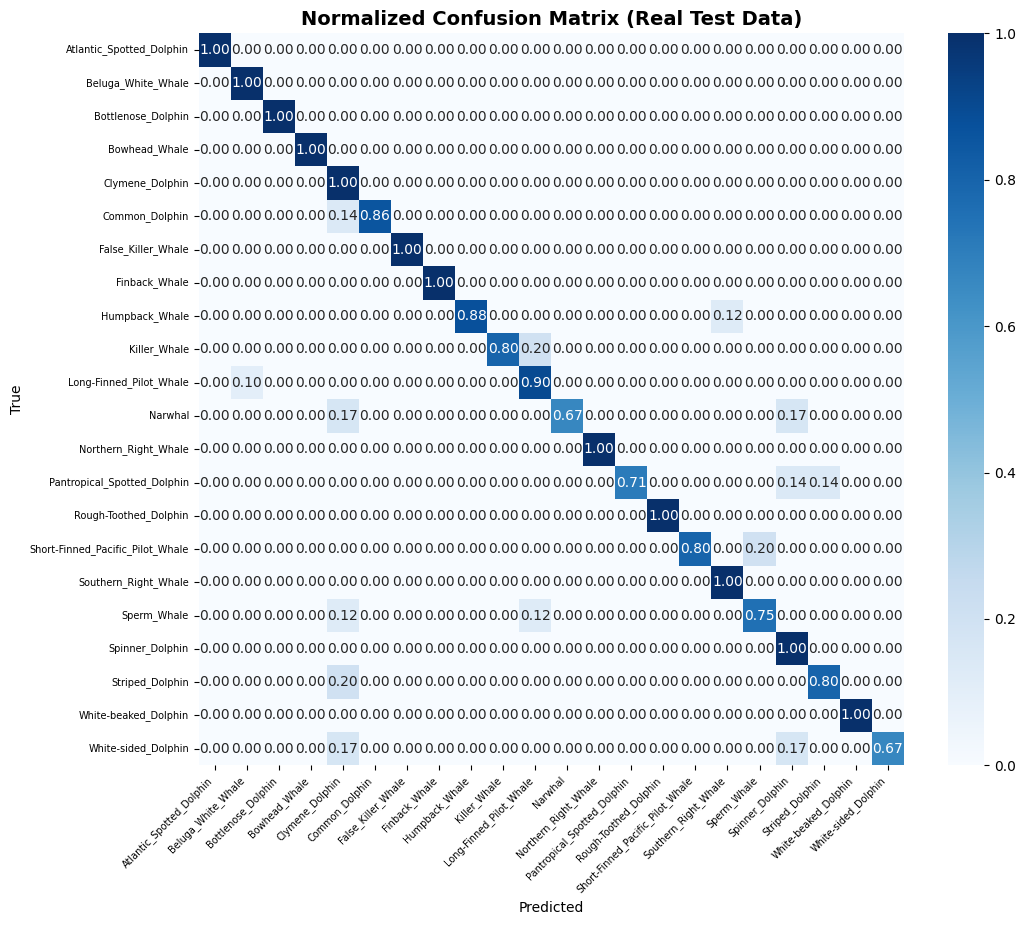

In [22]:
cm_norm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)), normalize='true')

fig_size = max(8, num_classes * 0.5)
plt.figure(figsize=(fig_size, fig_size * 0.85))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Normalized Confusion Matrix (Real Test Data)', fontsize=14, fontweight='bold')
plt.ylabel('True')
plt.xlabel('Predicted')

plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)

plt.tight_layout()
plt.show()

## 22. Save Everything

In [23]:
save_dir = '.'

# -----------------------------
# CNN MODEL SAVE
# -----------------------------
torch.save({
    'model_state_dict': model.state_dict(),
    'num_classes': num_classes,
    'class_names': list(label_encoder.classes_),

    # Input / preprocessing
    'input_shape': (1, N_MELS, TARGET_WIDTH),
    'sample_rate': SAMPLE_RATE,
    'n_mels': N_MELS,
    'target_width': TARGET_WIDTH,

    # Training info
    'test_accuracy': test_acc,
    'macro_f1': macro_f1,
    'history': history,

    # Hyperparameters
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'epochs': EPOCHS,

    # Augmentation info
    'augmentation': 'diffusion',
    'synth_per_class': SYNTH_PER_CLASS

}, os.path.join(save_dir, 'whale_cnn_diffusion_aug.pth'))

# -----------------------------
# DIFFUSION MODEL SAVE
# -----------------------------
torch.save({
    'model_state_dict': unet.state_dict(),
    'num_classes': num_classes,
    'class_names': list(label_encoder.classes_),
    'img_size': IMG_SIZE,
    'timesteps': TIMESTEPS
}, os.path.join(save_dir, 'diffusion_unet.pth'))

# -----------------------------
# LABEL ENCODER
# -----------------------------
with open(os.path.join(save_dir, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_encoder, f)

# -----------------------------
# TRAINING HISTORY
# -----------------------------
pd.DataFrame(history).to_csv(
    os.path.join(save_dir, 'training_history_diffusion.csv'),
    index=False
)

# -----------------------------
# CONFUSION MATRIX SAVE
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
np.save(os.path.join(save_dir, 'confusion_matrix.npy'), cm)

print("Saved all model artifacts successfully.")

Saved all model artifacts successfully.


## 23. Inference

In [24]:
def predict_audio(audio_path, model, label_encoder, device, top_k=3, return_spec=False):
    model.eval()

    audio, sr = load_audio(audio_path)
    if audio is None:
        return None, None, None if not return_spec else (None, None, None, None)

    spec = compute_mel_spectrogram(audio, sr)
    if spec is None:
        return None, None, None if not return_spec else (None, None, None, None)

    tensor = torch.tensor(spec[np.newaxis, np.newaxis, :, :], dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    top_idx = np.argsort(probs)[::-1][:top_k]
    top_preds = [(label_encoder.inverse_transform([i])[0], float(probs[i])) for i in top_idx]

    pred_idx = top_idx[0]
    pred_label = label_encoder.inverse_transform([pred_idx])[0]
    pred_conf = float(probs[pred_idx])

    if return_spec:
        return pred_label, probs, pred_conf, spec, top_preds

    return pred_label, probs, pred_conf, top_preds

def show_prediction(audio_path, model, label_encoder, device):
    pred_label, probs, pred_conf, spec, top_preds = predict_audio(
        audio_path, model, label_encoder, device, top_k=5, return_spec=True
    )

    if pred_label is None:
        print("Could not process audio.")
        return

    print(f"Predicted class: {pred_label}")
    print(f"Confidence: {pred_conf:.4f}")
    print("\nTop 5 predictions:")
    for name, p in top_preds:
        print(f"  {name:30s} {p:.4f}")

    plt.figure(figsize=(10, 4))
    plt.imshow(spec, aspect='auto', origin='lower', cmap='magma')
    plt.title(f"Spectrogram - Predicted: {pred_label}")
    plt.xlabel("Time")
    plt.ylabel("Mel Bins")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

## 24. App.py Compatibility: Train Two-Stage Gate + Whale Species Models

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix

WHALE_KEYWORDS = ("whale", "beluga", "narwhal")

def is_whale_class_name(name: str) -> bool:
    n = str(name).lower()
    return any(k in n for k in WHALE_KEYWORDS)

# Build masks from the full dataset loaded earlier in the notebook.
class_names_all = np.array(label_encoder.classes_)
class_is_whale = np.array([is_whale_class_name(n) for n in class_names_all])
if class_is_whale.sum() < 2:
    raise ValueError("Need at least 2 whale classes to train whale_species_classifier.")

# Integer class ids in the full label space.
whale_class_ids = set(np.where(class_is_whale)[0].tolist())

# -----------------------------
# Gate dataset (Whale vs Not Whale)
# -----------------------------
y_gate = np.array([1 if int(lbl) in whale_class_ids else 0 for lbl in y], dtype=np.int64)

X_gate_train, X_gate_test, y_gate_train, y_gate_test = train_test_split(
    X, y_gate, test_size=TEST_SIZE, random_state=42, stratify=y_gate
)

X_gate_train, X_gate_val, y_gate_train, y_gate_val = train_test_split(
    X_gate_train,
    y_gate_train,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=42,
    stratify=y_gate_train,
)

train_gate_ds = WhaleSpectrogramDataset(X_gate_train, y_gate_train, augment=True)
val_gate_ds = WhaleSpectrogramDataset(X_gate_val, y_gate_val, augment=False)
test_gate_ds = WhaleSpectrogramDataset(X_gate_test, y_gate_test, augment=False)

train_gate_loader = DataLoader(train_gate_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_gate_loader = DataLoader(val_gate_ds, batch_size=BATCH_SIZE, shuffle=False)
test_gate_loader = DataLoader(test_gate_ds, batch_size=BATCH_SIZE, shuffle=False)

# Class weights for imbalanced binary gate labels.
gate_counts = np.bincount(y_gate_train)
gate_weights = 1.0 / np.maximum(gate_counts, 1)
gate_weights = gate_weights / gate_weights.sum() * len(gate_weights)
criterion_gate = nn.CrossEntropyLoss(weight=torch.FloatTensor(gate_weights).to(device))

gate_model = WhaleCNN(num_classes=2).to(device)
gate_optimizer = optim.Adam(gate_model.parameters(), lr=LEARNING_RATE)
gate_scheduler = optim.lr_scheduler.ReduceLROnPlateau(gate_optimizer, mode='min', factor=0.5, patience=4)

best_gate_acc = 0.0
best_gate_wts = copy.deepcopy(gate_model.state_dict())
gate_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\nTraining gate model (Not Whale vs Whale)...")
for epoch in range(EPOCHS):
    tl, ta = train_epoch(gate_model, train_gate_loader, criterion_gate, gate_optimizer)
    vl, va = val_epoch(gate_model, val_gate_loader, criterion_gate)
    gate_scheduler.step(vl)

    gate_history['train_loss'].append(tl)
    gate_history['train_acc'].append(ta)
    gate_history['val_loss'].append(vl)
    gate_history['val_acc'].append(va)

    if va > best_gate_acc:
        best_gate_acc = va
        best_gate_wts = copy.deepcopy(gate_model.state_dict())

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Gate Epoch {epoch+1:>3d}/{EPOCHS} | train_acc={ta:.4f} | val_acc={va:.4f}")

gate_model.load_state_dict(best_gate_wts)
gate_model.eval()

# Evaluate gate on held-out gate test set.
y_gate_true, y_gate_pred = [], []
with torch.no_grad():
    for xb, yb in test_gate_loader:
        xb = xb.to(device)
        logits = gate_model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        y_gate_pred.extend(preds)
        y_gate_true.extend(yb.numpy())

y_gate_true = np.array(y_gate_true)
y_gate_pred = np.array(y_gate_pred)
gate_test_acc = accuracy_score(y_gate_true, y_gate_pred)
gate_cm = confusion_matrix(y_gate_true, y_gate_pred, labels=[0, 1])
gate_cm_norm = confusion_matrix(y_gate_true, y_gate_pred, labels=[0, 1], normalize='true')

print(f"Gate best val acc: {best_gate_acc:.4f}")
print(f"Gate test acc:     {gate_test_acc:.4f}")

# -----------------------------
# Whale-only species dataset
# -----------------------------
whale_mask = np.array([int(lbl) in whale_class_ids for lbl in y], dtype=bool)
X_whale = X[whale_mask]
y_whale_old = y[whale_mask]

# Re-encode whale classes to a compact 0..K-1 index set for app.py species model.
whale_label_encoder = LabelEncoder()
whale_label_encoder.fit(class_names_all[class_is_whale])
y_whale_names = class_names_all[y_whale_old]
y_whale = whale_label_encoder.transform(y_whale_names)

X_sp_train, X_sp_test, y_sp_train, y_sp_test = train_test_split(
    X_whale, y_whale, test_size=TEST_SIZE, random_state=42, stratify=y_whale
)

X_sp_train, X_sp_val, y_sp_train, y_sp_val = train_test_split(
    X_sp_train,
    y_sp_train,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=42,
    stratify=y_sp_train,
)

train_sp_ds = WhaleSpectrogramDataset(X_sp_train, y_sp_train, augment=True)
val_sp_ds = WhaleSpectrogramDataset(X_sp_val, y_sp_val, augment=False)
test_sp_ds = WhaleSpectrogramDataset(X_sp_test, y_sp_test, augment=False)

train_sp_loader = DataLoader(train_sp_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_sp_loader = DataLoader(val_sp_ds, batch_size=BATCH_SIZE, shuffle=False)
test_sp_loader = DataLoader(test_sp_ds, batch_size=BATCH_SIZE, shuffle=False)

sp_counts = np.bincount(y_sp_train)
sp_weights = 1.0 / np.maximum(sp_counts, 1)
sp_weights = sp_weights / sp_weights.sum() * len(sp_weights)
criterion_sp = nn.CrossEntropyLoss(weight=torch.FloatTensor(sp_weights).to(device))

species_model = WhaleCNN(num_classes=len(whale_label_encoder.classes_)).to(device)
sp_optimizer = optim.Adam(species_model.parameters(), lr=LEARNING_RATE)
sp_scheduler = optim.lr_scheduler.ReduceLROnPlateau(sp_optimizer, mode='min', factor=0.5, patience=4)

best_sp_acc = 0.0
best_sp_wts = copy.deepcopy(species_model.state_dict())
species_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\nTraining whale species model (whale classes only)...")
for epoch in range(EPOCHS):
    tl, ta = train_epoch(species_model, train_sp_loader, criterion_sp, sp_optimizer)
    vl, va = val_epoch(species_model, val_sp_loader, criterion_sp)
    sp_scheduler.step(vl)

    species_history['train_loss'].append(tl)
    species_history['train_acc'].append(ta)
    species_history['val_loss'].append(vl)
    species_history['val_acc'].append(va)

    if va > best_sp_acc:
        best_sp_acc = va
        best_sp_wts = copy.deepcopy(species_model.state_dict())

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Species Epoch {epoch+1:>3d}/{EPOCHS} | train_acc={ta:.4f} | val_acc={va:.4f}")

species_model.load_state_dict(best_sp_wts)
species_model.eval()

# Evaluate whale species model on held-out whale test set.
y_sp_true, y_sp_pred = [], []
with torch.no_grad():
    for xb, yb in test_sp_loader:
        xb = xb.to(device)
        logits = species_model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        y_sp_pred.extend(preds)
        y_sp_true.extend(yb.numpy())

y_sp_true = np.array(y_sp_true)
y_sp_pred = np.array(y_sp_pred)
species_test_acc = accuracy_score(y_sp_true, y_sp_pred)
species_cm = confusion_matrix(y_sp_true, y_sp_pred, labels=list(range(len(whale_label_encoder.classes_))))
species_cm_norm = confusion_matrix(
    y_sp_true,
    y_sp_pred,
    labels=list(range(len(whale_label_encoder.classes_))),
    normalize='true'
)

print(f"Species best val acc: {best_sp_acc:.4f}")
print(f"Species test acc:     {species_test_acc:.4f}")

# -----------------------------
# Save app.py-compatible artifacts
# -----------------------------
SAVE_DIR = '.'

torch.save({
    'model_state_dict': gate_model.state_dict(),
    'class_names': ['Dolphin', 'Whale'],
    'whale_gate_threshold': 0.60,
    'sample_rate': SAMPLE_RATE,
    'n_mels': N_MELS,
    'target_width': TARGET_WIDTH,
    'best_val_acc': float(best_gate_acc),
    'test_acc': float(gate_test_acc),
    'history': gate_history,
}, os.path.join(SAVE_DIR, 'whale_gate_classifier.pth'))

torch.save({
    'model_state_dict': species_model.state_dict(),
    'num_classes': int(len(whale_label_encoder.classes_)),
    'class_names': list(whale_label_encoder.classes_),
    'sample_rate': SAMPLE_RATE,
    'n_mels': N_MELS,
    'target_width': TARGET_WIDTH,
    'best_val_acc': float(best_sp_acc),
    'test_acc': float(species_test_acc),
    'history': species_history,
}, os.path.join(SAVE_DIR, 'whale_species_classifier.pth'))

with open(os.path.join(SAVE_DIR, 'whale_species_label_encoder.pkl'), 'wb') as f:
    pickle.dump(whale_label_encoder, f)

np.save(os.path.join(SAVE_DIR, 'gate_confusion_matrix.npy'), gate_cm)
np.save(os.path.join(SAVE_DIR, 'gate_confusion_matrix_normalized.npy'), gate_cm_norm)
np.save(os.path.join(SAVE_DIR, 'species_confusion_matrix.npy'), species_cm)
np.save(os.path.join(SAVE_DIR, 'species_confusion_matrix_normalized.npy'), species_cm_norm)

pd.DataFrame(gate_history).to_csv(os.path.join(SAVE_DIR, 'gate_training_history.csv'), index=False)

print("\nSaved app.py-compatible artifacts:")
print("  - whale_gate_classifier.pth")
print("  - whale_species_classifier.pth")
print("  - whale_species_label_encoder.pkl")
print("  - gate/species confusion matrix .npy files")
print("  - gate_training_history.csv")


Training gate model (Not Whale vs Whale)...
  Gate Epoch   1/75 | train_acc=0.6482 | val_acc=0.3967
  Gate Epoch  10/75 | train_acc=0.8528 | val_acc=0.7521
  Gate Epoch  20/75 | train_acc=0.9025 | val_acc=0.9256
  Gate Epoch  30/75 | train_acc=0.9350 | val_acc=0.8843
  Gate Epoch  40/75 | train_acc=0.9465 | val_acc=0.9256
  Gate Epoch  50/75 | train_acc=0.9675 | val_acc=0.9504
  Gate Epoch  60/75 | train_acc=0.9598 | val_acc=0.9504
  Gate Epoch  70/75 | train_acc=0.9503 | val_acc=0.9504
Gate best val acc: 0.9752
Gate test acc:     0.9074

Training whale species model (whale classes only)...
  Species Epoch   1/75 | train_acc=0.2381 | val_acc=0.0822
  Species Epoch  10/75 | train_acc=0.7175 | val_acc=0.6301
  Species Epoch  20/75 | train_acc=0.8381 | val_acc=0.7534
  Species Epoch  30/75 | train_acc=0.9079 | val_acc=0.9041
  Species Epoch  40/75 | train_acc=0.9587 | val_acc=0.9589
  Species Epoch  50/75 | train_acc=0.9873 | val_acc=0.9452
  Species Epoch  60/75 | train_acc=0.9905 | val